In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import os
import tqdm
import numpy as np
import pandas as pd
import seaborn
import matplotlib.pyplot as plt 

from fragments_h5 import FragmentsH5

from fragmentomics_tools.region import Region
from fragmentomics_tools.dataframe import RegionDataFrame, DataFrameBase
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays

tqdm.tqdm.pandas()

In [73]:
from data import HematopoieticGeneExpression

In [26]:
from lib import make_single_strand_bndry, make_on_off_plots, load_ibd_sample_df

In [31]:
from lib import NUM_CORES, DEFAULT_MIN_MAPQ, DEFAULT_MAX_FRAG_LEN, BOUNDARY_EXPANSION_SIZE

In [80]:
df = HematopoieticGeneExpression.load()

# Make Gene-Boundary Aligned Coverage Plots

In [21]:
hge = HematopoieticGeneExpression.load()

In [22]:
hge = hge.expand_regions(left=BOUNDARY_EXPANSION_SIZE, right=BOUNDARY_EXPANSION_SIZE, strand_aware=True)

In [28]:
srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(hge, load_ibd_sample_df()).attach_fragment_arrays(num_cores=64)
srdf['n_fragments']  = [fa.n_fragments for fa in srdf.fragment_array]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312354/312354 [04:30<00:00, 1155.56it/s]


In [97]:
from fragmentomics_tools.plot.tracks import Tracks, VLine, VplotTrack, CoverageDifferenceTrack, StrandSplitCoverageTrack, VectorTrack, CoverageTrack

(<Figure size 2500x400 with 2 Axes>, [<Axes: >, <Axes: xlabel='chr19'>])

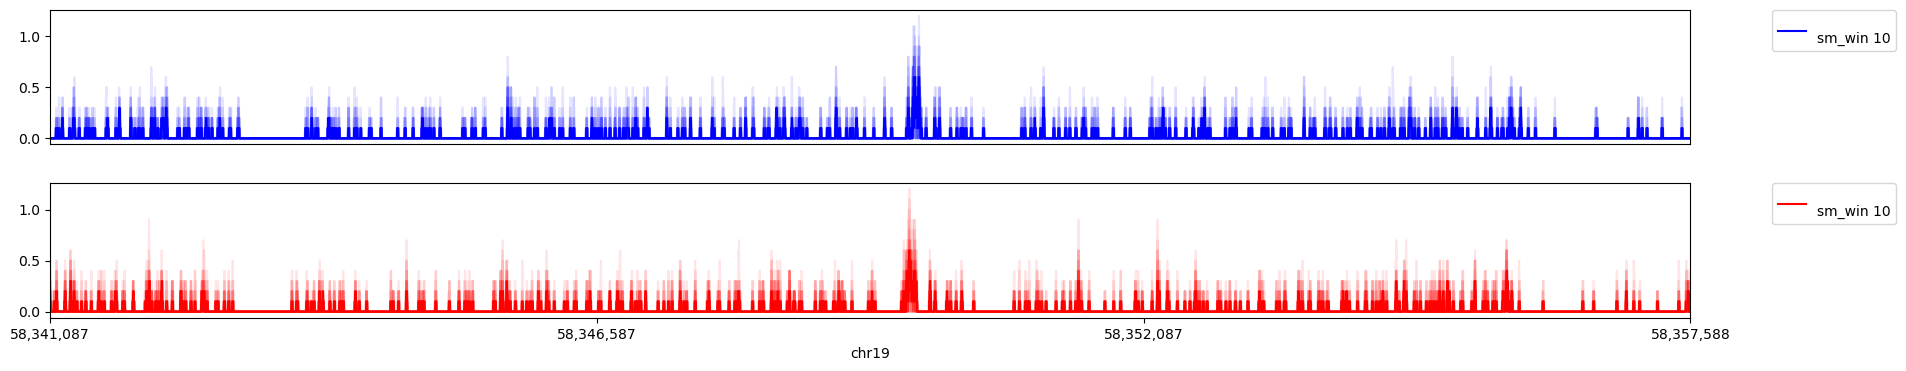

In [108]:
tracks = Tracks()

a = CoverageTrack(srdf.fragment_array.tolist()[0], coverage_type='right_endpoint')
b = CoverageTrack(srdf.fragment_array.tolist()[0], coverage_type='left_endpoint')
Tracks([a, b]).plot(sharey=True)

CPU times: user 1min 27s, sys: 24.1 s, total: 1min 51s
Wall time: 1min 48s


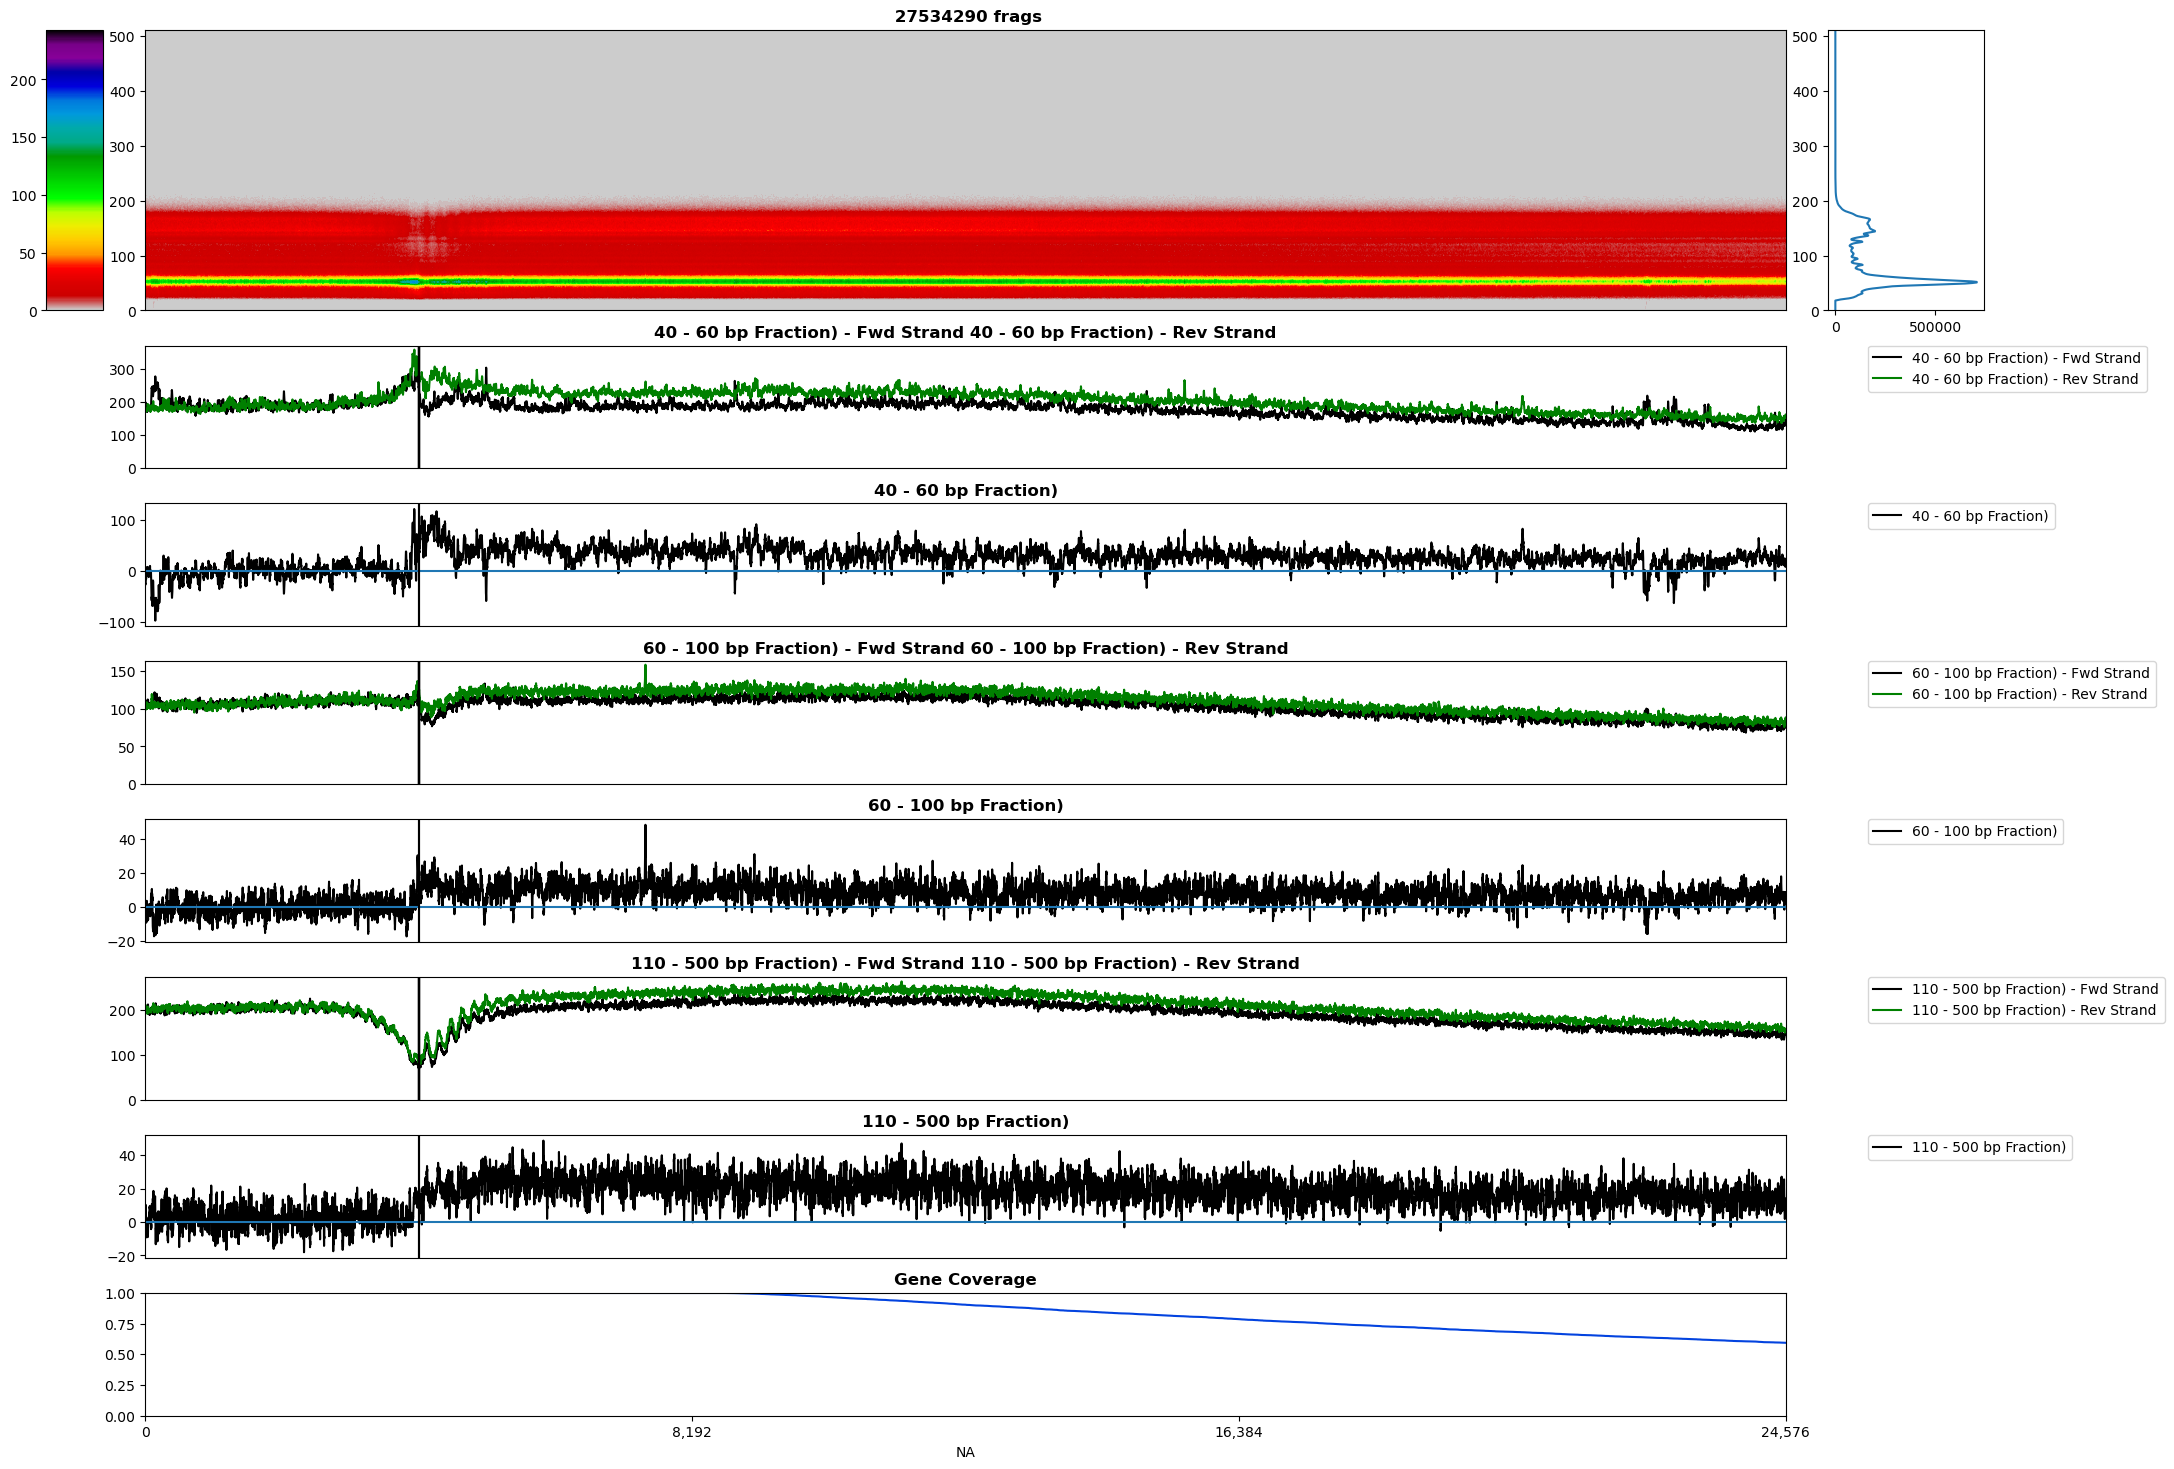

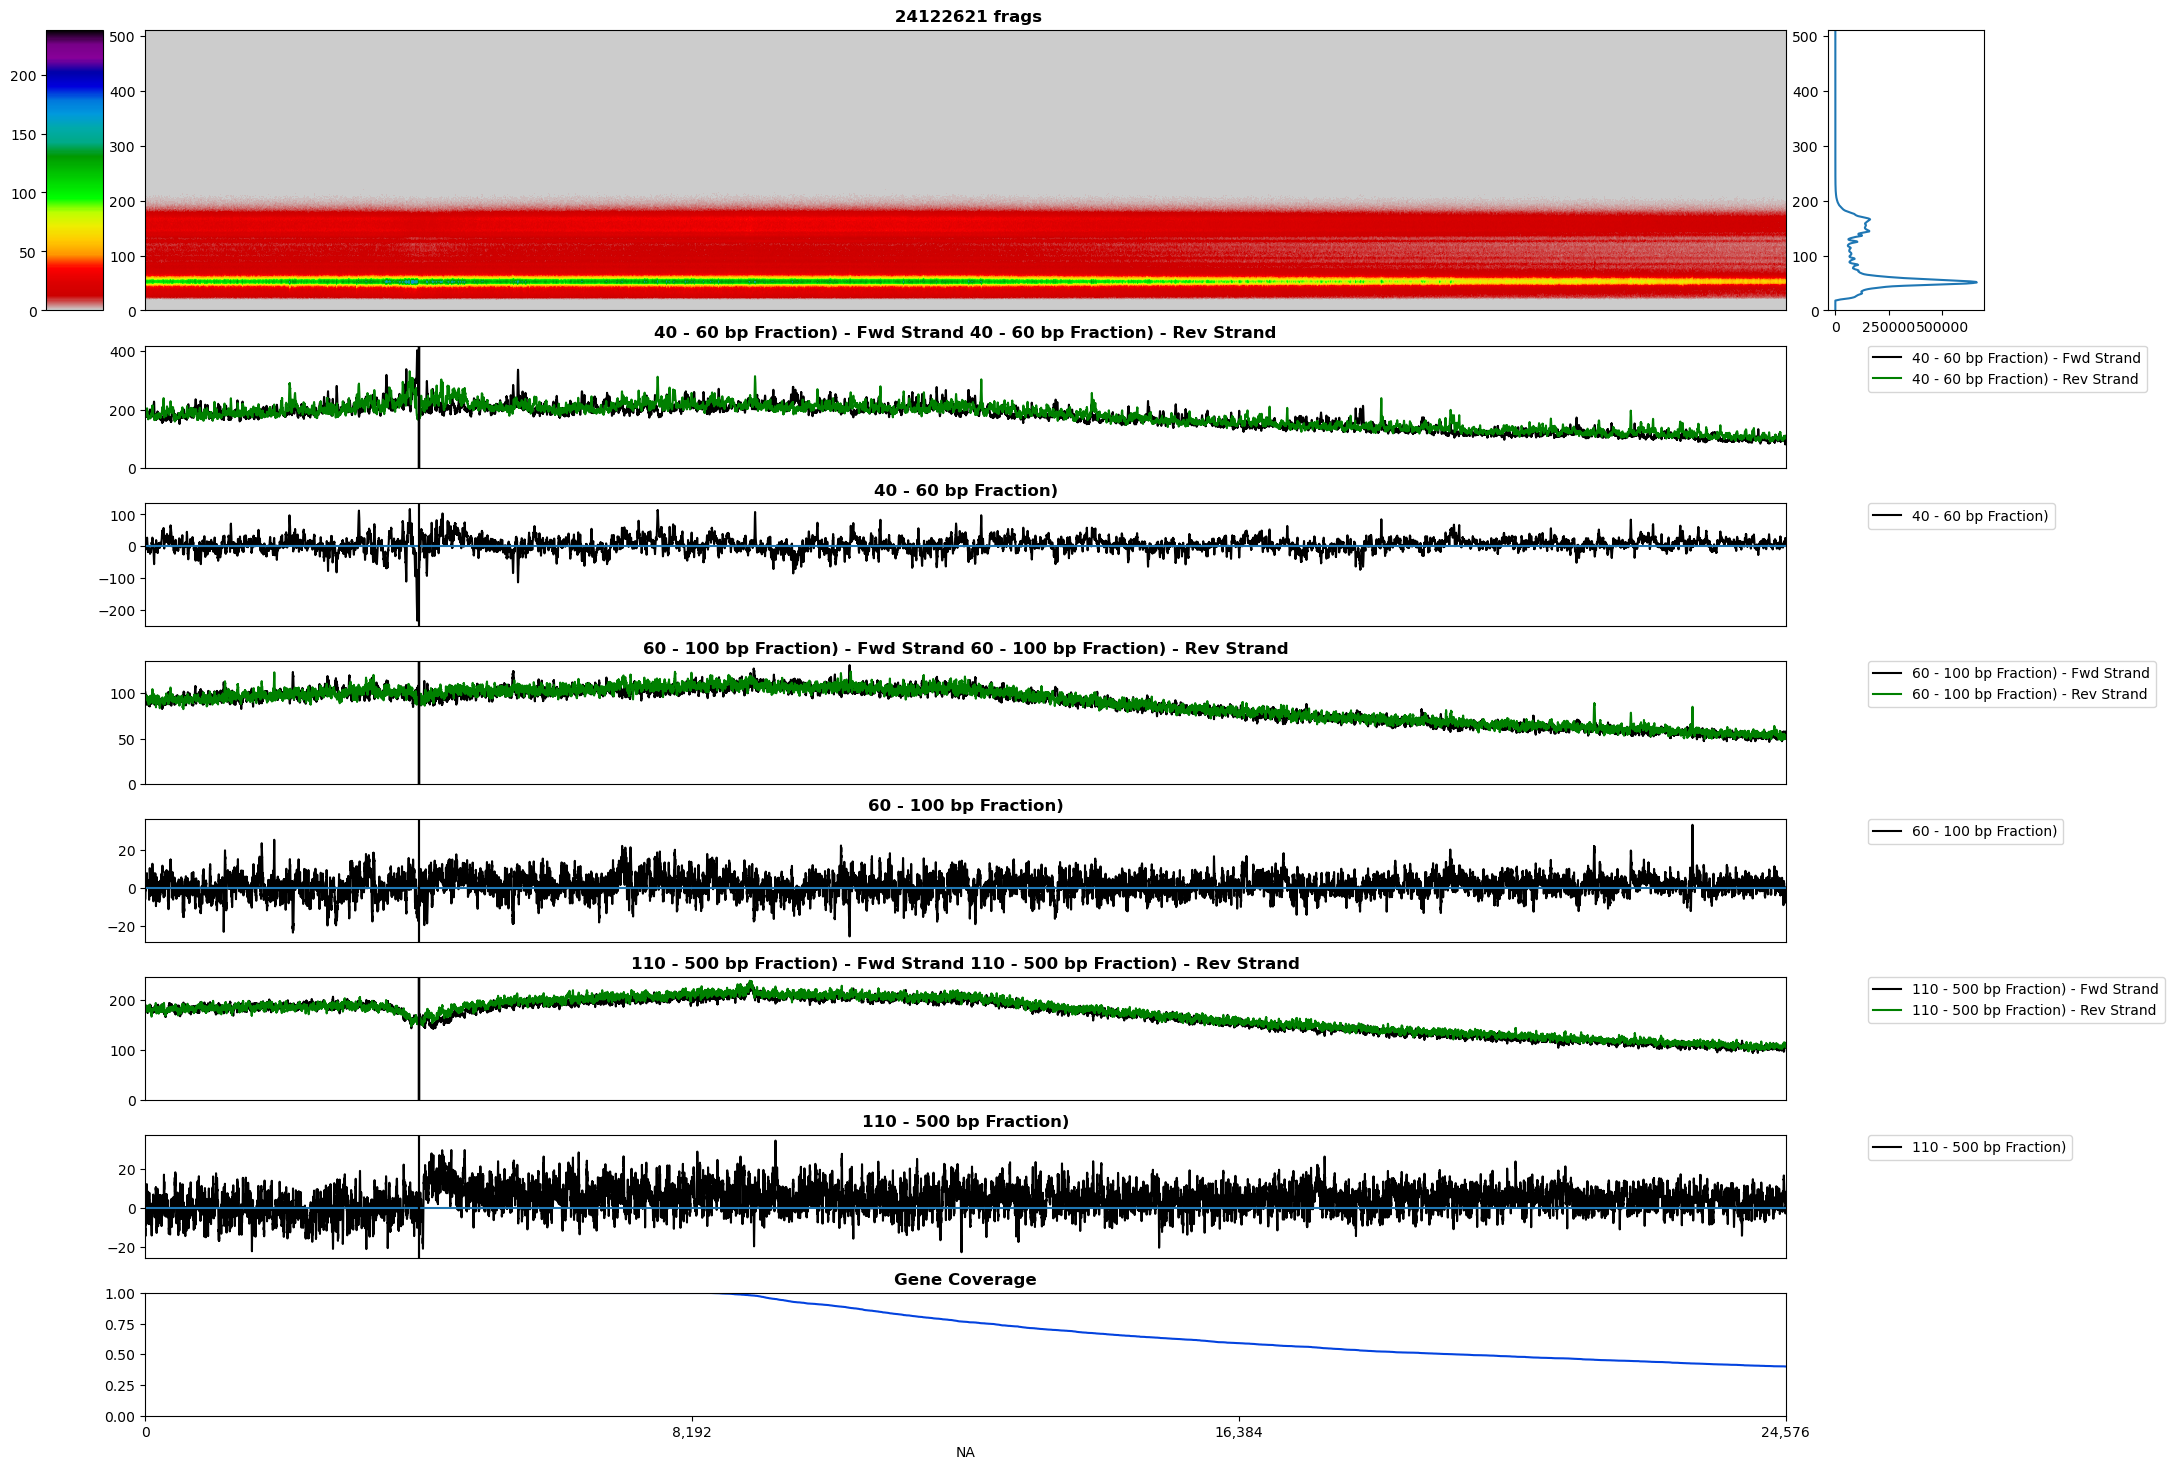

In [36]:
%%time
make_on_off_plots(srdf, 'tss')

# Score Regions

In [37]:
new_tpm_ranges = [(0, 0.1), (0.1, 1), (1, 5), (5, 10), (10, 20), (20, 70), (70, 500)]

def add_tpm_bucket(df):
    df['tpm_bucket'] = None
    for i, (start, stop) in enumerate(new_tpm_ranges):
        df.loc[(start <= df.expression) & (df.expression < stop), 'tpm_bucket'] = f"{i+1}: TPM {str(start).zfill(1)}-{str(stop).zfill(1)}"
    return df


def score_fa(record, low_fl=40, high_fl=500):
    fa = record.fragment_array.drop_duplicate_fragments()
    fa = fa.subset_fragment_lengths(low_fl, high_fl)
    strands, counts = np.unique(fa.fragment_strands, return_counts=True)
    if fa.strand == '+':
        fwd_mask = (strands == '+')
    elif fa.strand == '-':
        fwd_mask = (strands == '-')
    else:
        assert False, f"UNREACHABLE: ({fa.strand})"

    if counts.sum() < 100:
        return None

    res = (counts[~fwd_mask] - counts[fwd_mask])/counts.sum()
    assert len(res) == 1
    return float(res[0])


In [38]:
df = add_tpm_bucket(srdf)

In [39]:
scores = df.progress_apply(score_fa, axis=1).rename('score')
scores = RegionDataFrame(pd.concat([pd.DataFrame(df), scores], axis=1), ref=df.ref)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312354/312354 [02:37<00:00, 1982.83it/s]


In [40]:
scores.head()

,gene_name,gene_id,contig,strand,start,stop,expression,sample_id,label,frag_h5,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,fragment_array,n_fragments,tpm_bucket,score
0,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56170,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 2,Site_13,"RegionFragmentArray(n_frags=402, region=chr19:...",402,6: TPM 20-70,-0.044444
1,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56169,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 6,Site_13,"RegionFragmentArray(n_frags=492, region=chr19:...",492,6: TPM 20-70,-0.166667
2,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56168,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=265, region=chr19:...",265,6: TPM 20-70,-0.020747
3,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56167,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 1,Site_13,"RegionFragmentArray(n_frags=397, region=chr19:...",397,6: TPM 20-70,0.005618
4,A1BG,ENSG00000121410,chr19,-,58341087,58357588,62.542394,RD-56165,1,<fragments_h5.fragments_h5.FragmentsH5 object ...,Ulcerative Colitis,Remission,Patient Group 3,Site_13,"RegionFragmentArray(n_frags=232, region=chr19:...",232,6: TPM 20-70,-0.187215


In [41]:
scores.groupby('tpm_bucket').score.agg(['count', 'mean', 'std'])

,count,mean,std
tpm_bucket,,,
1: TPM 0-0.1,70289,0.007375,0.099525
2: TPM 0.1-1,33037,0.019284,0.094312
3: TPM 1-5,30554,0.021335,0.087046
4: TPM 5-10,20225,0.032456,0.081793
5: TPM 10-20,30147,0.036533,0.081636
6: TPM 20-70,70912,0.041762,0.079961
7: TPM 70-500,45427,0.044054,0.081560


# Marker Gene Analysis

In [42]:
marker_genes = pd.read_table("/scratch/karius/reference/markers.immune_vs_epithelial.tsv", sep=" ")
up_marker_genes = marker_genes.query("p_val_adj < 0.01 and avg_log2FC < -4").assign(direction='up_in_colon')
down_marker_genes = marker_genes.query("p_val_adj < 0.01 and avg_log2FC > 7").assign(direction='down_in_colon')
marker_genes = pd.concat([up_marker_genes, down_marker_genes])
marker_genes = pd.DataFrame(scores).set_index("gene_name").join(marker_genes, how='inner').reset_index()

In [43]:
pd.DataFrame(marker_genes.groupby(["label", 'sample_id', "direction"]).score.agg(['count', 'mean']).reset_index()).rename(columns={'mean': 'mean_score'}).groupby(["label", "direction"])[['mean_score', 'count']].agg(['mean', 'std'])

mean_score                 count          
                          mean       std        mean       std
label direction                                               
1     down_in_colon   0.016132  0.006737  157.333333  1.211060
      up_in_colon    -0.022540  0.013743   25.000000  0.000000
2     down_in_colon   0.012916  0.004940  157.800000  0.447214
      up_in_colon    -0.013078  0.005452   25.000000  0.000000
3     down_in_colon   0.014665  0.002209  157.750000  0.500000
      up_in_colon    -0.007471  0.005717   25.000000  0.000000
4     down_in_colon   0.017796  0.003126  155.666667  4.041452
      up_in_colon    -0.007157  0.008938   24.666667  0.577350

# Visualize Individual Genes

In [60]:
_3 = marker_genes.query("direction == 'up_in_colon' and label==3").set_index(['gene_id', 'gene_name'])[['score']]
_1 = marker_genes.query("direction == 'up_in_colon' and label==1").set_index(['gene_id', 'gene_name'])[['score']]
df = pd.DataFrame(_1.groupby(_1.index).score.agg('mean').sort_values()).join(_3.groupby(_3.index).score.mean().sort_values(), how='inner',  lsuffix='_remission', rsuffix='_severe')

In [109]:
df

,gene_name,gene_id,contig,strand,start,stop,expression
0,A1BG,ENSG00000121410,chr19,-,58345183,58353492,62.542394
1,A1CF,ENSG00000148584,chr10,-,50799409,50859985,0.000000
2,A2M,ENSG00000175899,chr12,-,9067708,9115919,0.077835
3,A2ML1,ENSG00000166535,chr12,+,8822621,8875012,0.197852
4,A4GALT,ENSG00000128274,chr22,-,42692121,42695631,2.158199
...,...,...,...,...,...,...,...
17348,ZXDC,ENSG00000070476,chr3,-,126437601,126475891,19.699126
17349,ZYG11A,ENSG00000203995,chr1,+,52842511,52893790,0.000000
17350,ZYG11B,ENSG00000162378,chr1,+,52726453,52805524,28.688477
17351,ZYX,ENSG00000159840,chr7,+,143381345,143391109,118.715634


In [62]:
(df.score_severe - df.score_remission).sort_values()

(ENSG00000204571, KRTAP5-11)   -0.067202
(ENSG00000160868, CYP3A4)      -0.028790
(ENSG00000168748, CA7)         -0.020723
(ENSG00000204614, TRIM40)      -0.014126
(ENSG00000073737, DHRS9)       -0.012134
(ENSG00000137869, CYP19A1)     -0.002727
(ENSG00000166828, SCNN1G)       0.000779
(ENSG00000073734, ABCB11)       0.000889
(ENSG00000168447, SCNN1B)       0.001422
(ENSG00000175329, ISX)          0.002451
(ENSG00000039987, BEST2)        0.003598
(ENSG00000214814, FER1L6)       0.004506
(ENSG00000142959, BEST4)        0.012302
(ENSG00000106536, POU6F2)       0.012709
(ENSG00000204539, CDSN)         0.013979
(ENSG00000166183, ASPG)         0.018356
(ENSG00000261210, CLEC19A)      0.022399
(ENSG00000196091, MYBPC1)       0.022526
(ENSG00000011083, SLC6A7)       0.026133
(ENSG00000198488, B3GNT6)       0.039607
(ENSG00000105996, HOXA2)        0.042820
(ENSG00000169876, MUC17)        0.052069
(ENSG00000167800, TBX10)        0.060327
(ENSG00000137251, TINAG)        0.080036
(ENSG00000105523

Text(0.5, 0.98, 'FAM83E')

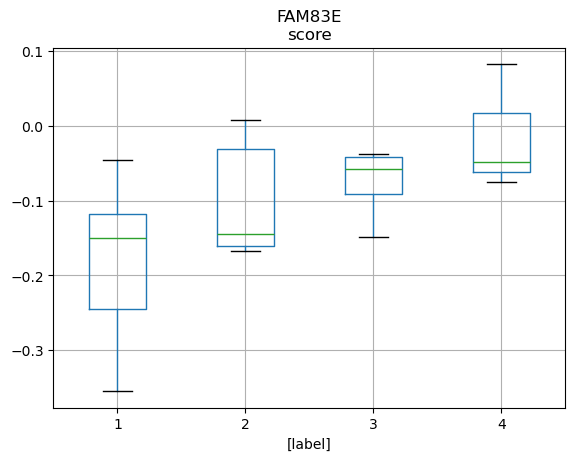

In [63]:
GENE_NAME = 'FAM83E'
sub_df = scores.query("gene_name.str.startswith(@GENE_NAME)")
pd.DataFrame(sub_df)[['label', 'score']].boxplot(by='label')
plt.suptitle(GENE_NAME)

In [194]:
fa = merge_fragment_arrays([fa.drop_duplicate_fragments() for fa in sub_df.fragment_array])
fa.region

Region(chr19:+:48595865-48618723)

In [199]:
fa = fa.truncate(right_amt=BOUNDARY_EXPANSION_SIZE)
fa.region # truncate(right_amt=BOUNDARY_EXPANSION_SIZE*2).region

Region(chr19:+:48595865-48610531)

In [195]:
from fragmentomics_tools.plot.tracks import GeneTrack, BedTrack
tracks = make_single_strand_bndry(fa)
tracks.append(GeneTrack("/home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38_extras/gencode.v28.basic.annotation.bed.gz", fa.region))
tracks.insert(1, BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", fa.region))
# tracks.append(BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/GRCh38_unified_blacklist.bed.gz", fa.region))

[W::hts_idx_load3] The index file is older than the data file: /home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38_extras/gencode.v28.basic.annotation.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38_extras/gencode.v28.basic.annotation.bed.gz.tbi


(<Figure size 2500x2000 with 11 Axes>,
 [<Axes: title={'center': ' 10019 frags'}>,
  <Axes: >,
  <Axes: title={'center': '40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <Axes: title={'center': '40 - 60 bp Fraction)'}>,
  <Axes: title={'center': '60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <Axes: title={'center': '60 - 100 bp Fraction)'}>,
  <Axes: title={'center': '110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <Axes: title={'center': '110 - 500 bp Fraction)'}>,
  <Axes: xlabel='chr19'>])

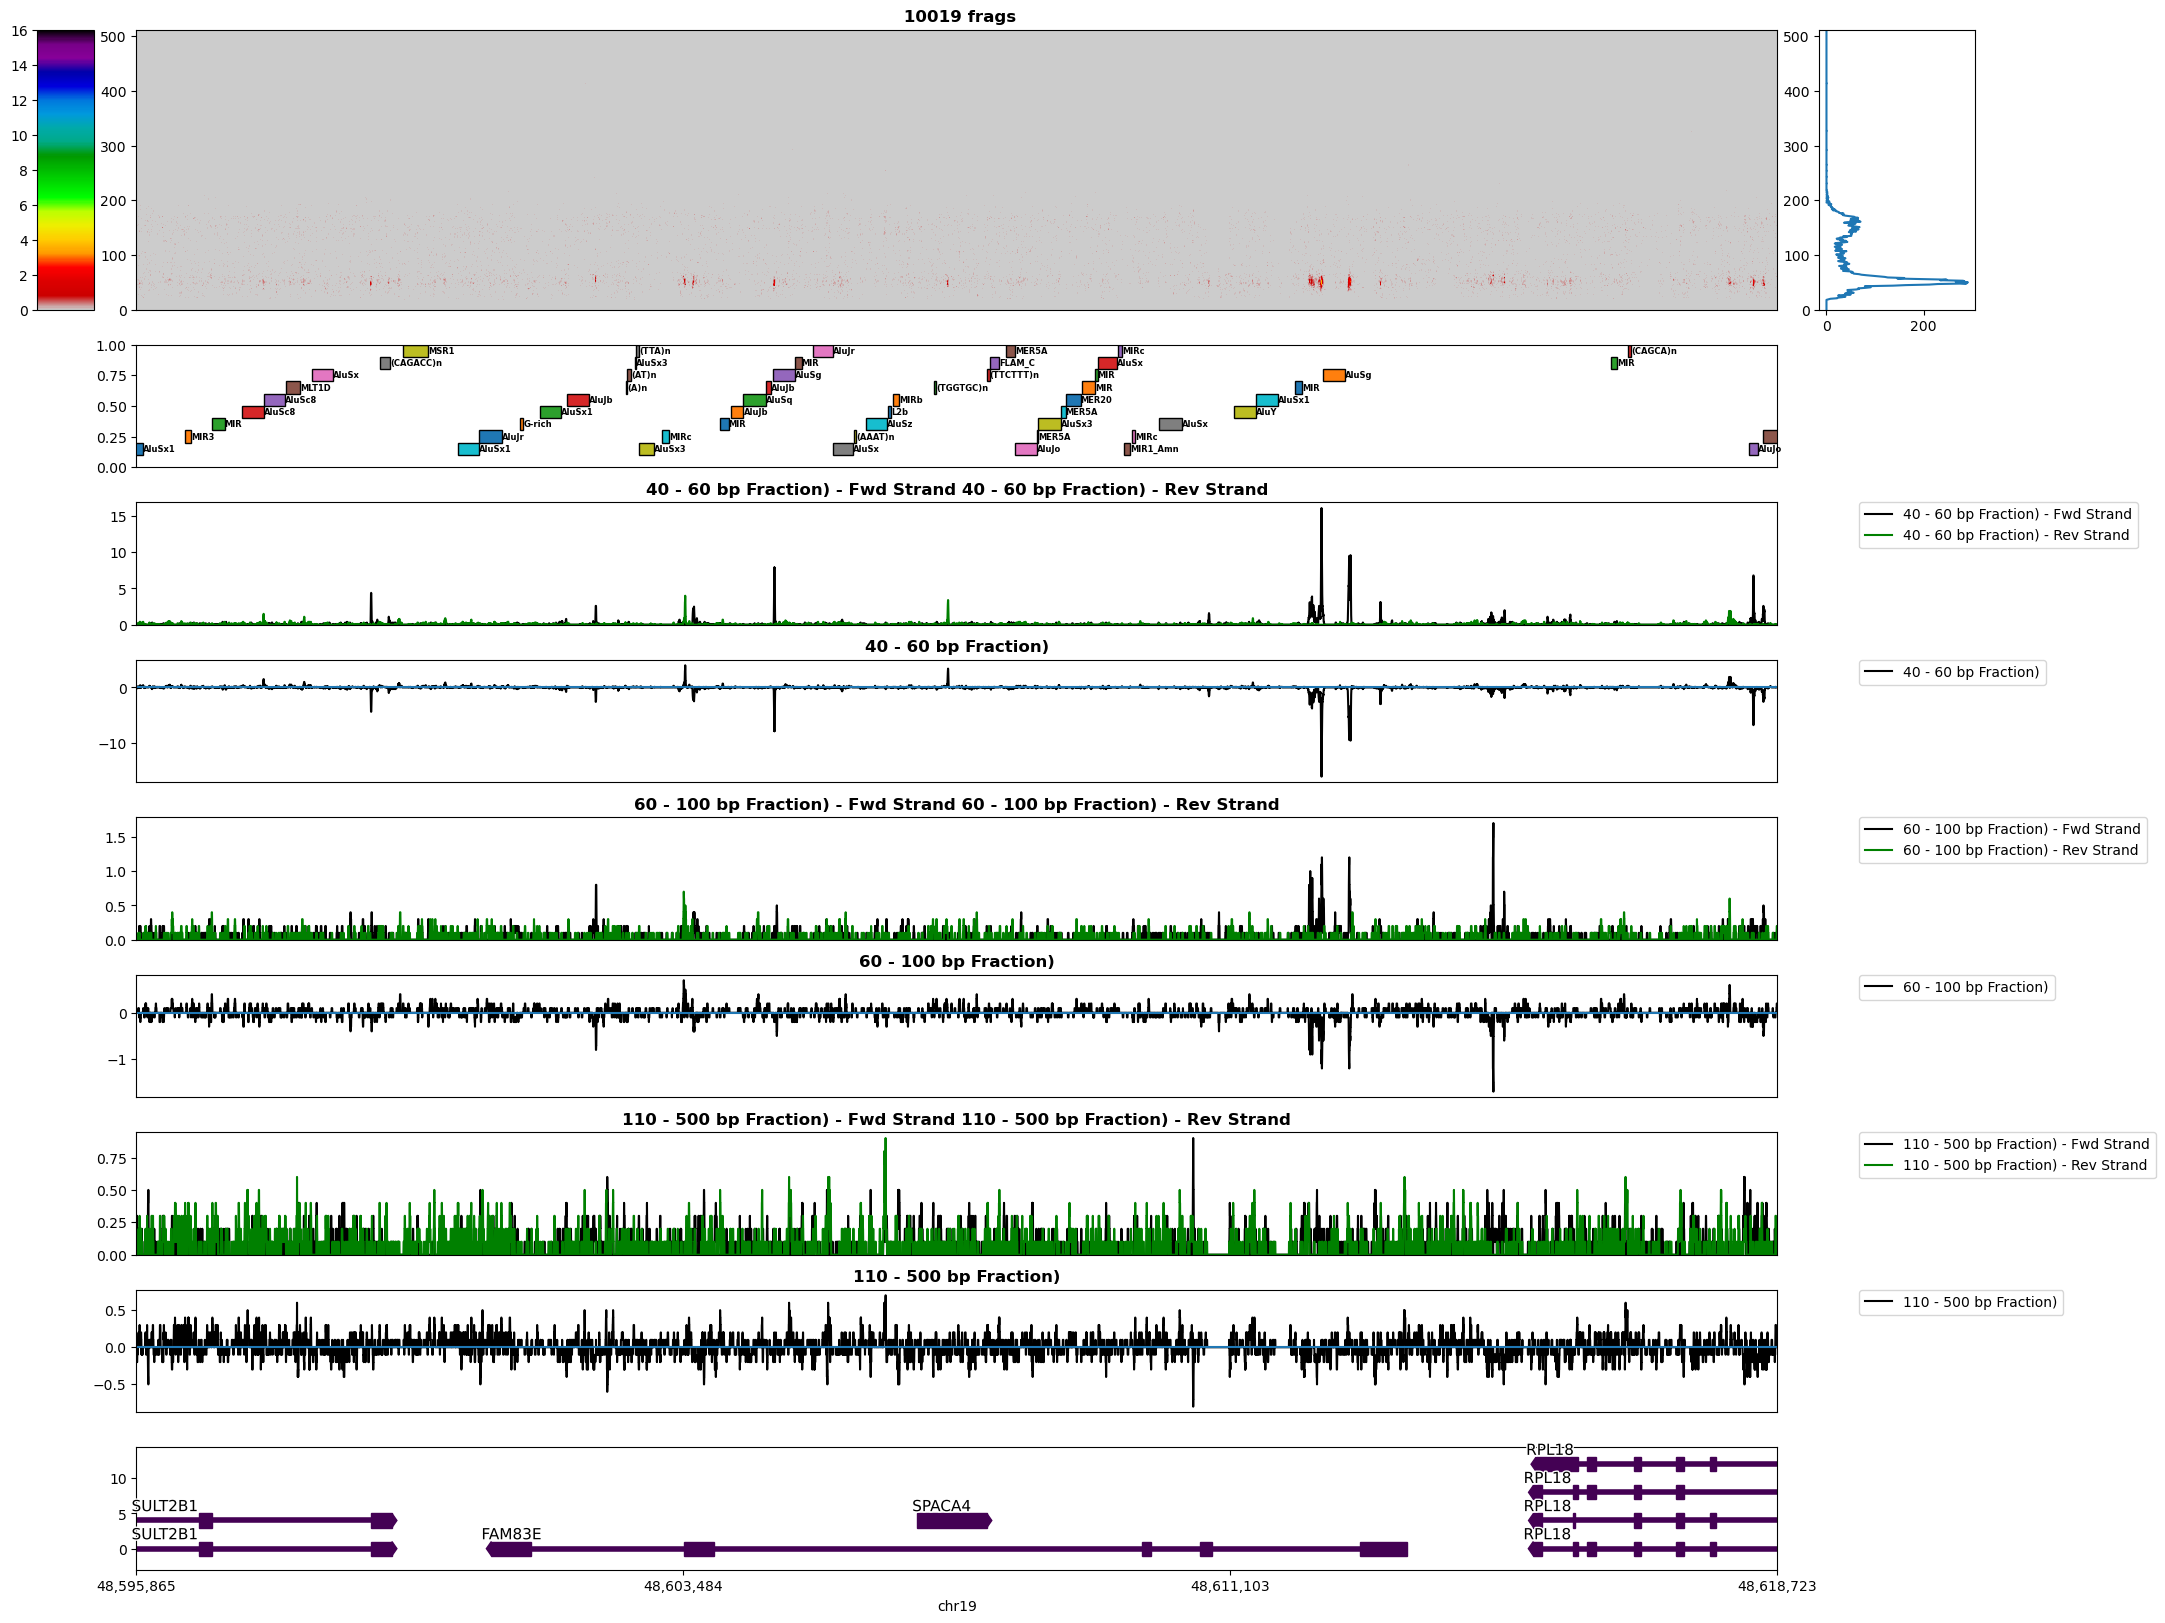

In [196]:
tracks.plot()

[W::hts_idx_load3] The index file is older than the data file: /home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38_extras/gencode.v28.basic.annotation.bed.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38_extras/gencode.v28.basic.annotation.bed.gz.tbi


(<Figure size 2500x200 with 1 Axes>, [<Axes: xlabel='chr19'>])

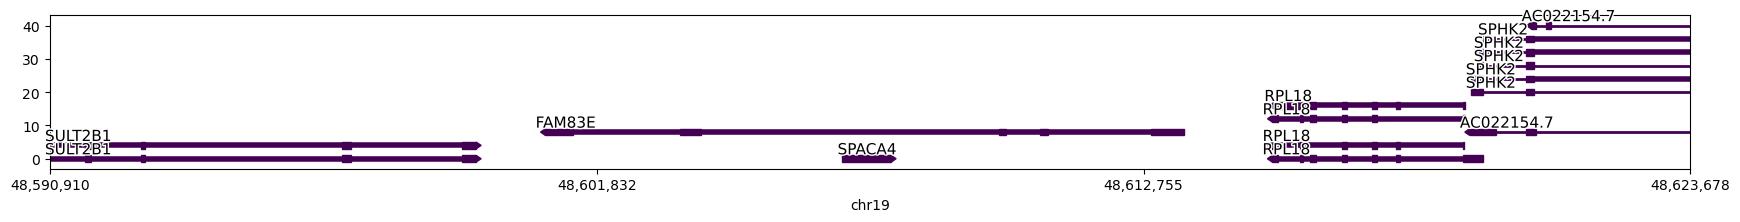

In [ ]:
tracks.append(load_genome_coverage_track('hg38'))
tracks.append(load_motif_track('CTCF'))

In [ ]:
# Loading samples
# standardized for loading samples for different anaysis
load_ibd_sample_df()
Samples.load_collection('ibd_pilot') -> sdf

# Loading reference data
gencode
hg38 fasta
blacklist
motif_pwms

